In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

df = pd.read_parquet("../data/processed/loans_clean.parquet")
print(f"Loaded {len(df):,} rows")
print(f"Quarters: {df['issue_quarter'].nunique()} | Range: {df['issue_quarter'].min()} – {df['issue_quarter'].max()}")

Loaded 2,258,957 rows
Quarters: 47 | Range: 2007Q2 – 2018Q4


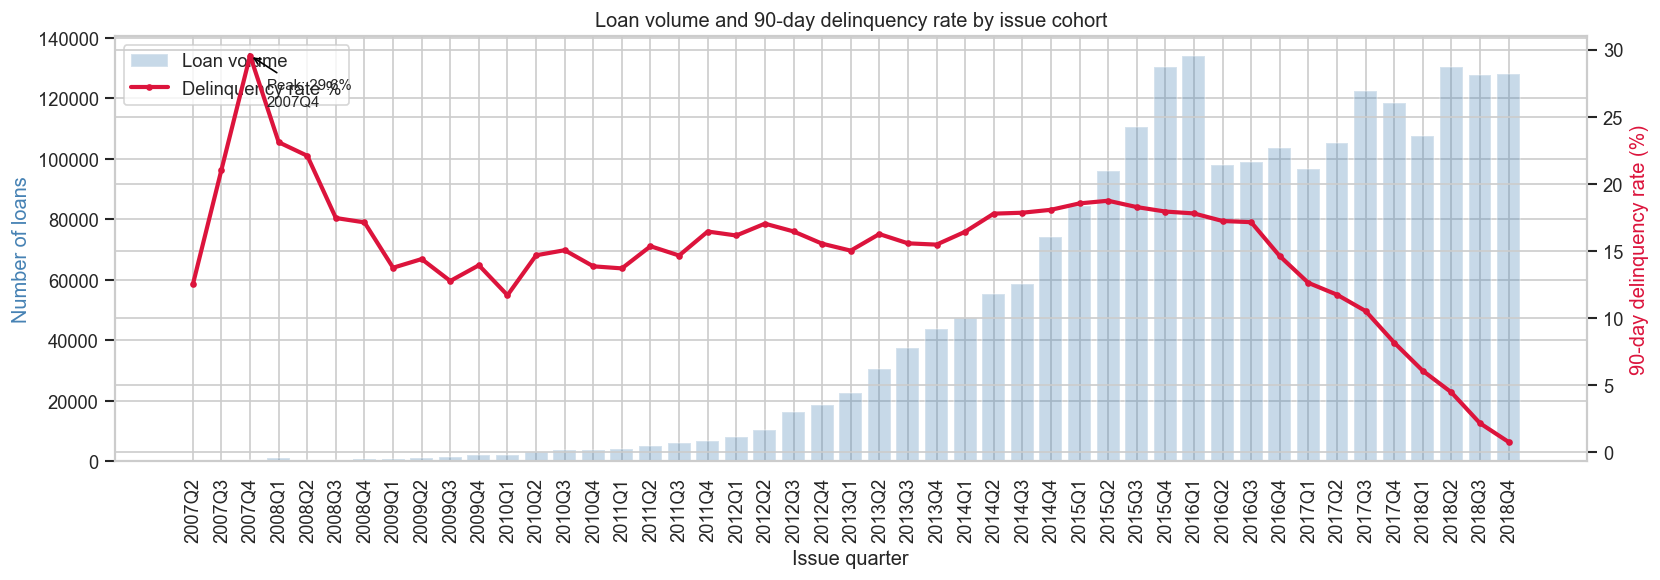


Worst cohort: 2007Q4 — 29.6% delinquency
Best cohort:  2018Q4 — 0.8%


In [2]:
# Delinquency rate by issue cohort
cohort = (df.groupby("issue_quarter")
            .agg(n_loans=("delq90", "count"),
                 delq_rate=("delq90", "mean"))
            .reset_index())

fig, ax1 = plt.subplots(figsize=(14, 5))

# Bar chart: loan volume
ax1.bar(cohort["issue_quarter"], cohort["n_loans"],
        color="steelblue", alpha=0.3, label="Loan volume")
ax1.set_ylabel("Number of loans", color="steelblue")
ax1.tick_params(axis="x", rotation=90)
ax1.set_xlabel("Issue quarter")

# Line: delinquency rate
ax2 = ax1.twinx()
ax2.plot(cohort["issue_quarter"], cohort["delq_rate"] * 100,
         color="crimson", linewidth=2.5, marker="o",
         markersize=3, label="Delinquency rate %")
ax2.set_ylabel("90-day delinquency rate (%)", color="crimson")

# Annotate the worst cohort
worst = cohort.loc[cohort["delq_rate"].idxmax()]
ax2.annotate(f"Peak: {worst['delq_rate']*100:.1f}%\n{worst['issue_quarter']}",
             xy=(worst["issue_quarter"], worst["delq_rate"] * 100),
             xytext=(10, -30), textcoords="offset points",
             arrowprops=dict(arrowstyle="->", color="black"),
             fontsize=9)

ax1.set_title("Loan volume and 90-day delinquency rate by issue cohort")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig("../output/figures/cohort_delinquency.png", dpi=150)
plt.show()

print(f"\nWorst cohort: {worst['issue_quarter']} — {worst['delq_rate']*100:.1f}% delinquency")
print(f"Best cohort:  {cohort.loc[cohort['delq_rate'].idxmin(), 'issue_quarter']} — {cohort['delq_rate'].min()*100:.1f}%")

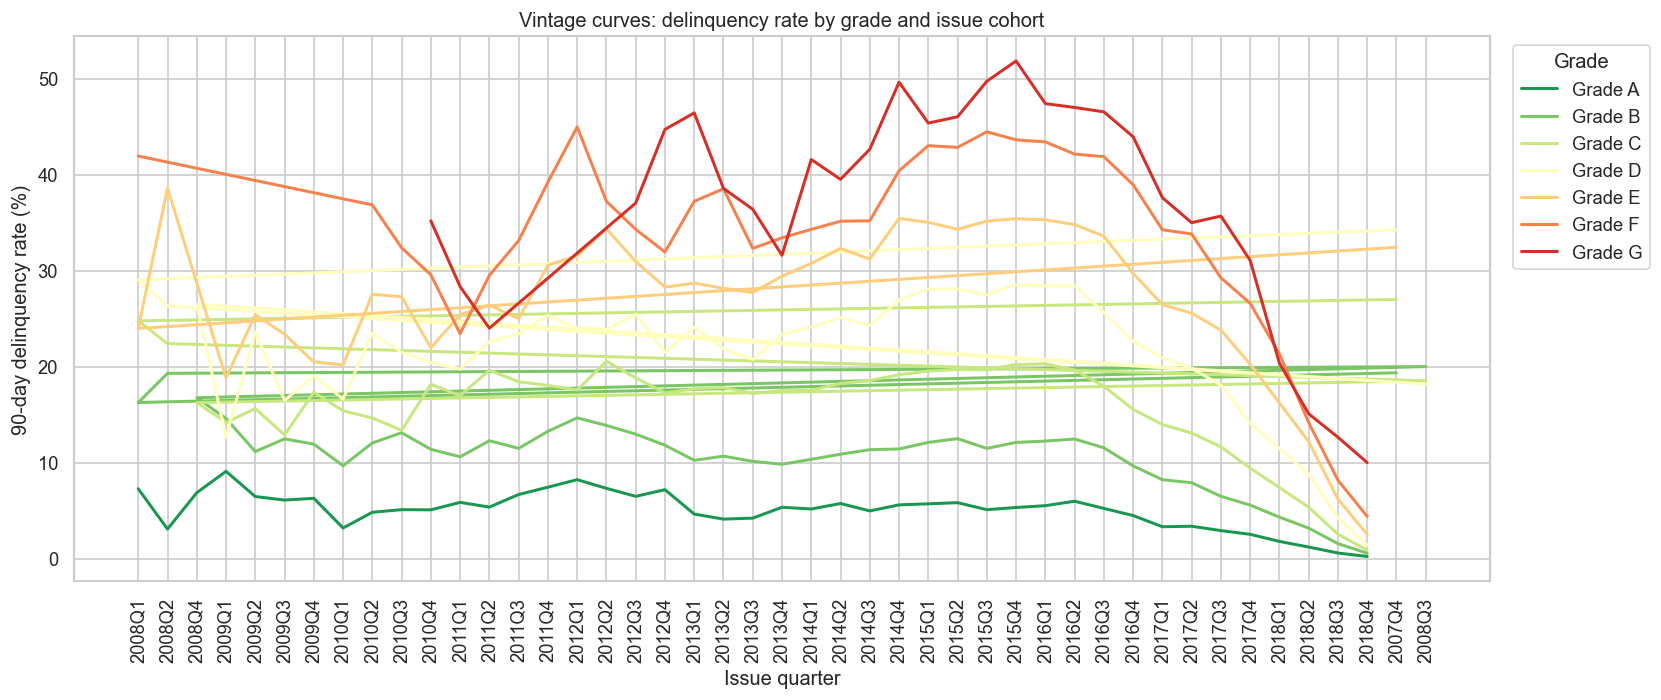

In [3]:
# Vintage curves: delinquency rate by grade over time
cohort_grade = (df.groupby(["issue_quarter", "grade"])
                  .agg(delq_rate=("delq90", "mean"),
                       n_loans=("delq90", "count"))
                  .reset_index())

# Only keep grades with enough loans
cohort_grade = cohort_grade[cohort_grade["n_loans"] >= 50]

grades = sorted(df["grade"].dropna().unique())
colors = cm.RdYlGn_r(np.linspace(0.1, 0.9, len(grades)))

fig, ax = plt.subplots(figsize=(14, 6))

for grade, color in zip(grades, colors):
    data = cohort_grade[cohort_grade["grade"] == grade]
    ax.plot(data["issue_quarter"], data["delq_rate"] * 100,
            label=f"Grade {grade}", color=color, linewidth=1.8)

ax.set_xlabel("Issue quarter")
ax.set_ylabel("90-day delinquency rate (%)")
ax.set_title("Vintage curves: delinquency rate by grade and issue cohort")
ax.tick_params(axis="x", rotation=90)
ax.legend(title="Grade", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.savefig("../output/figures/vintage_curves_by_grade.png",
            dpi=150, bbox_inches="tight")
plt.show()

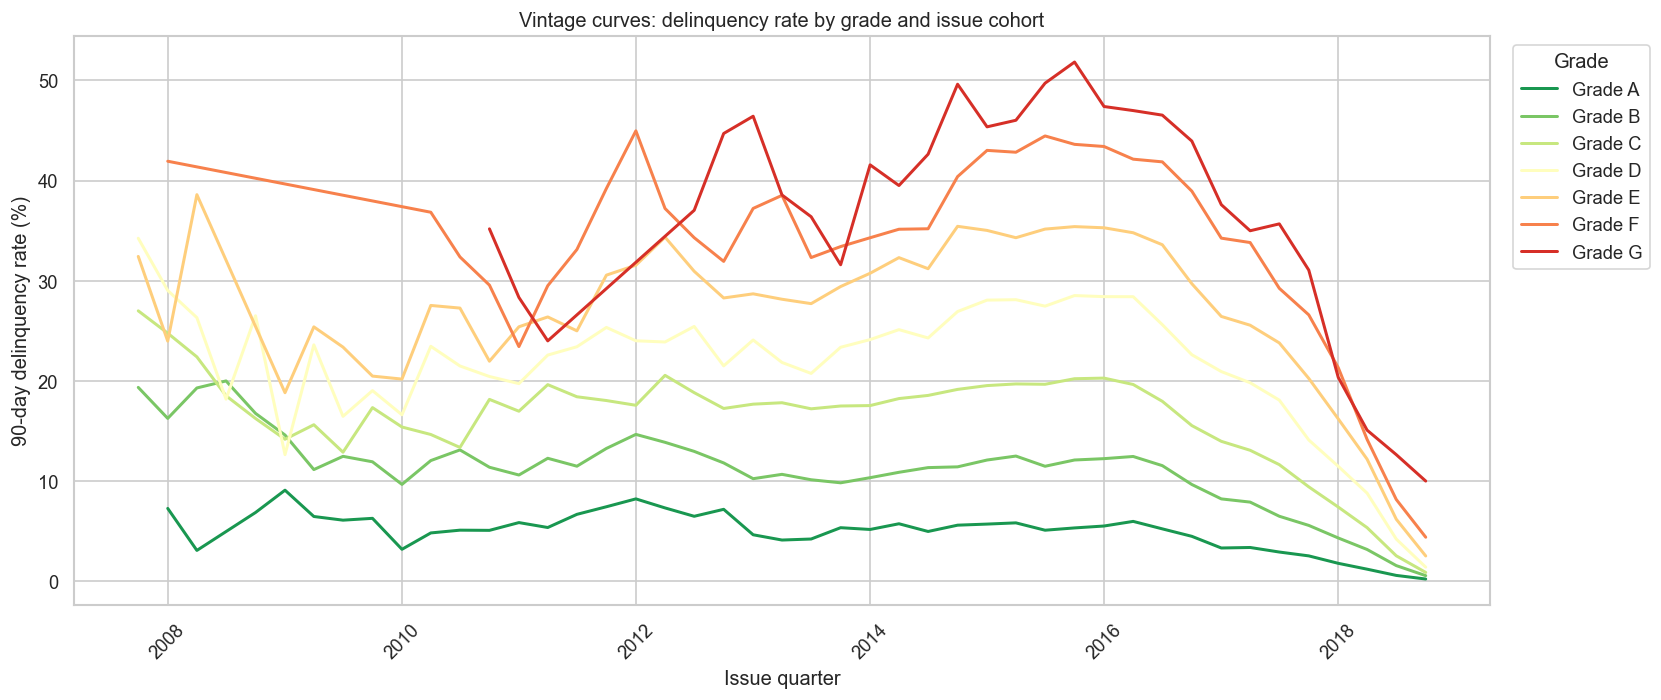

In [4]:
# Fix: sort quarters chronologically
cohort_grade["issue_quarter"] = pd.PeriodIndex(
    cohort_grade["issue_quarter"], freq="Q")
cohort_grade = cohort_grade.sort_values("issue_quarter")

grades = sorted(df["grade"].dropna().unique())
colors = cm.RdYlGn_r(np.linspace(0.1, 0.9, len(grades)))

fig, ax = plt.subplots(figsize=(14, 6))

for grade, color in zip(grades, colors):
    data = cohort_grade[cohort_grade["grade"] == grade]
    ax.plot(data["issue_quarter"].dt.to_timestamp(),
            data["delq_rate"] * 100,
            label=f"Grade {grade}", color=color, linewidth=1.8)

ax.set_xlabel("Issue quarter")
ax.set_ylabel("90-day delinquency rate (%)")
ax.set_title("Vintage curves: delinquency rate by grade and issue cohort")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Grade", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.savefig("../output/figures/vintage_curves_by_grade.png",
            dpi=150, bbox_inches="tight")
plt.show()

C:\Users\Nathaniel\AppData\Local\Temp\ipykernel_18640\3368756546.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["issue_year"] = pd.to_datetime(


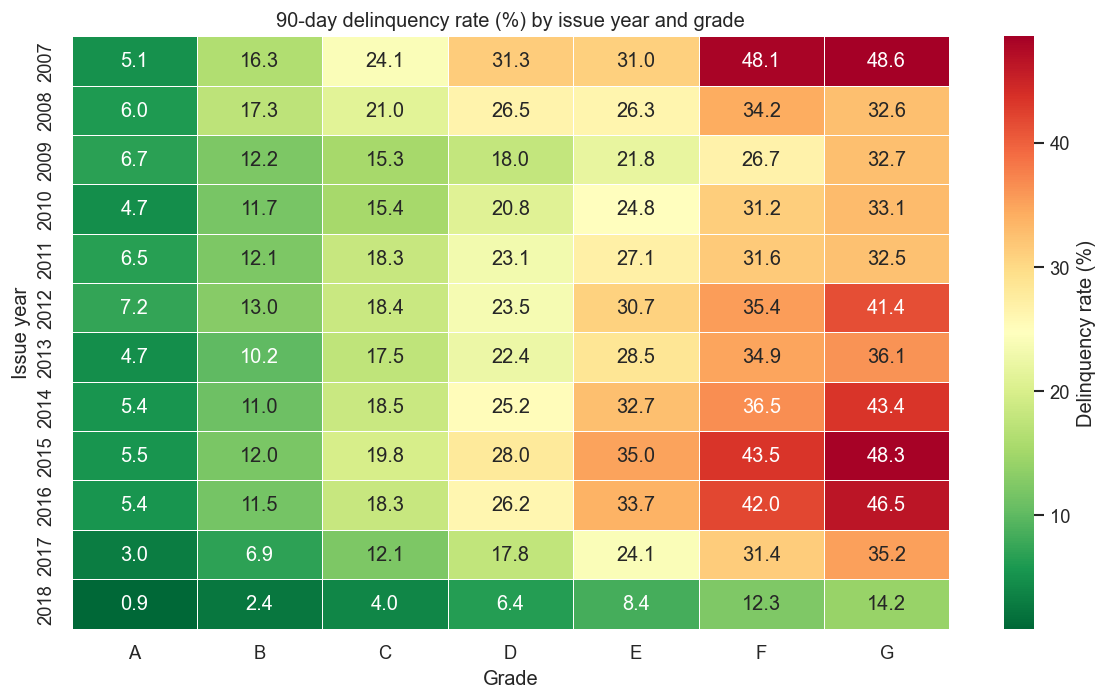

In [5]:
# Heatmap: delinquency rate by grade and year
df["issue_year"] = pd.to_datetime(
    df["issue_quarter"].astype(str)).dt.year

pivot = (df.groupby(["issue_year", "grade"])["delq90"]
           .mean()
           .unstack("grade")
           .sort_index() * 100)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r",
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "Delinquency rate (%)"})

ax.set_title("90-day delinquency rate (%) by issue year and grade")
ax.set_xlabel("Grade")
ax.set_ylabel("Issue year")
plt.tight_layout()
plt.savefig("../output/figures/delinquency_heatmap_year_grade.png", dpi=150)
plt.show()